# Buy The Dip Strategy

In [8]:
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Any, Optional

# --- 1. Configuration Classes ---
@dataclass
class StrategyConfig:
    name: str
    holding_days: int = 5
    stop_loss_pct: float = 5.0
    take_profit_pct: float = 10.0
    ema_length: int = 200
    rsi_length: int = 2
    rsi_threshold: int = 15  # Connors RSI 2 usually uses low threshold like 10-15

# --- 2. The Strategy (Buy The Dip) ---
class BuyTheDipStrategy:
    def __init__(self, config: StrategyConfig):
        self.config = config

    def prepare_data(self, df: pd.DataFrame) -> pd.DataFrame:
        # Calculate Indicators
        df['EMA'] = ta.ema(df['Close'], length=self.config.ema_length)
        df['RSI'] = ta.rsi(df['Close'], length=self.config.rsi_length)
        
        # Logic: 
        # 1. Trend Filter: Price > EMA
        # 2. Dip Trigger: RSI < Threshold
        # 3. Clean Signal: Cross under (Today < Threshold AND Yesterday >= Threshold)
        
        trend_ok = df['Close'] > df['EMA']
        rsi_dip = (df['RSI'] < self.config.rsi_threshold) & (df['RSI'].shift(1) >= self.config.rsi_threshold)
        
        df['Signal'] = trend_ok & rsi_dip
        return df

    def check_exit_conditions(self, entry_price, current_close, current_low, current_high):
        # 1. Check Stop Loss (Intraday Low)
        if self.config.stop_loss_pct > 0:
            sl_price = entry_price * (1 - self.config.stop_loss_pct / 100)
            if current_low <= sl_price:
                return True, "STOP_LOSS"
        
        # 2. Check Take Profit (Intraday High)
        if self.config.take_profit_pct > 0:
            tp_price = entry_price * (1 + self.config.take_profit_pct / 100)
            if current_high >= tp_price:
                return True, "TAKE_PROFIT"
                
        return False, "HOLDING"

# --- 3. The Realistic Backtest Engine ---
class BacktestEngine:
    def __init__(self, initial_capital=10000.0, commission_pct=0.1):
        self.initial_capital = initial_capital
        self.commission_pct = commission_pct

    def run(self, df: pd.DataFrame, strategy: BuyTheDipStrategy):
        trades = []
        current_capital = self.initial_capital
        active_trade = None
        equity_curve = [current_capital] * len(df)
        
        # Loop Day-by-Day (Preventing Look-ahead bias)
        for i in range(len(df) - 1):
            curr_idx = df.index[i]
            next_idx = df.index[i+1]
            
            curr_row = df.iloc[i]
            next_row = df.iloc[i+1]
            
            # --- Manage Active Trade ---
            if active_trade:
                active_trade['days_held'] += 1
                
                should_exit, reason = strategy.check_exit_conditions(
                    entry_price=active_trade['entry_price'],
                    current_close=curr_row['Close'],
                    current_low=curr_row['Low'],
                    current_high=curr_row['High']
                )
                
                # Time-based Exit
                if active_trade['days_held'] >= strategy.config.holding_days:
                    should_exit = True
                    reason = "TIME_BASED"
                
                if should_exit:
                    # Exit at Close (Simplified)
                    exit_price = curr_row['Close']
                    shares = active_trade['shares']
                    
                    # Calcs
                    exit_value = shares * exit_price
                    commission = exit_value * (self.commission_pct / 100)
                    net_proceeds = exit_value - commission
                    current_capital += net_proceeds
                    
                    gross_pnl = (exit_price - active_trade['entry_price']) * shares
                    net_pnl = gross_pnl - (active_trade['commission'] + commission)
                    
                    trades.append({
                        'entry_date': active_trade['entry_date'],
                        'exit_date': curr_idx,
                        'entry_price': active_trade['entry_price'],
                        'exit_price': exit_price,
                        'pnl': net_pnl,
                        'return_pct': (net_pnl / active_trade['cost_basis']) * 100,
                        'reason': reason
                    })
                    
                    active_trade = None
            
            # --- Check Entry Signal ---
            # Enter only if no position & Signal is True
            if active_trade is None and curr_row['Signal'] == True:
                # EXECUTE AT NEXT OPEN
                entry_price = next_row['Open']
                
                # Position Sizing (Fixed 95% of capital)
                allocation = current_capital * 0.95
                shares = int(allocation / entry_price)
                
                if shares > 0:
                    cost = shares * entry_price
                    commission = cost * (self.commission_pct / 100)
                    current_capital -= (cost + commission)
                    
                    active_trade = {
                        'entry_date': next_idx,
                        'entry_price': entry_price,
                        'shares': shares,
                        'cost_basis': cost,
                        'commission': commission,
                        'days_held': 0
                    }
            
            # Record Equity (Cash + Market Value of Shares)
            market_value = 0
            if active_trade:
                market_value = active_trade['shares'] * curr_row['Close']
            equity_curve[i] = current_capital + market_value

        return trades, equity_curve

In [9]:
# 1. Download Data
symbol = "NVDA" # ลองเปลี่ยนเป็น AAPL, TSLA, BTC-USD ได้
df = yf.download(symbol, start="2023-01-01", end="2024-12-31", progress=False)
# yfinance multi-level column fix
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Setup Strategy & Engine
config = StrategyConfig(
    name="BTD_RSI2",
    holding_days=5,       # ถือ 5 วันถ้าไม่ชน SL/TP
    stop_loss_pct=5.0,    # คัทเมื่อลง 5%
    take_profit_pct=10.0, # ขายหมูเมื่อขึ้น 10%
    rsi_threshold=15      # RSI(2) < 15 ซื้อ
)

strategy = BuyTheDipStrategy(config)
engine = BacktestEngine(initial_capital=100000, commission_pct=0.1)

# 3. Prepare Data
df = strategy.prepare_data(df)
df = df.dropna() # ตัดช่วง warm-up indicator ทิ้ง

# 4. Run Backtest
trades, equity = engine.run(df, strategy)

# 5. Calculate Stats
trades_df = pd.DataFrame(trades)
if not trades_df.empty:
    total_trades = len(trades_df)
    win_rate = len(trades_df[trades_df['pnl'] > 0]) / total_trades * 100
    avg_pnl = trades_df['pnl'].mean()
    total_return = (equity[-2] - 100000) / 100000 * 100
    
    print(f"--- Result for {symbol} ---")
    print(f"Total Trades: {total_trades}")
    print(f"Win Rate: {win_rate:.2f}%")
    print(f"Total Return: {total_return:.2f}%")
    print(f"Avg PnL per trade: ${avg_pnl:.2f}")
    display(trades_df.tail()) # แสดง 5 เทรดล่าสุด
else:
    print("No trades found matching criteria.")

--- Result for NVDA ---
Total Trades: 20
Win Rate: 65.00%
Total Return: 57.58%
Avg PnL per trade: $2878.86


C:\Users\panuw\AppData\Local\Temp\ipykernel_47772\3103963808.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start="2023-01-01", end="2024-12-31", progress=False)


,entry_date,exit_date,entry_price,exit_price,pnl,return_pct,reason
15,2024-11-01,2024-11-07,134.653896,148.829056,13336.010163,10.316580,TIME_BASED
16,2024-11-18,2024-11-22,139.452234,141.901398,2206.830987,1.554518,TIME_BASED
17,2024-11-26,2024-12-03,137.652870,140.211990,2388.474233,1.657252,TIME_BASED
18,2024-12-10,2024-12-16,138.971975,131.963882,-7664.817334,-5.237767,TIME_BASED
19,2024-12-17,2024-12-23,129.054692,139.631805,11112.484136,7.987642,TIME_BASED


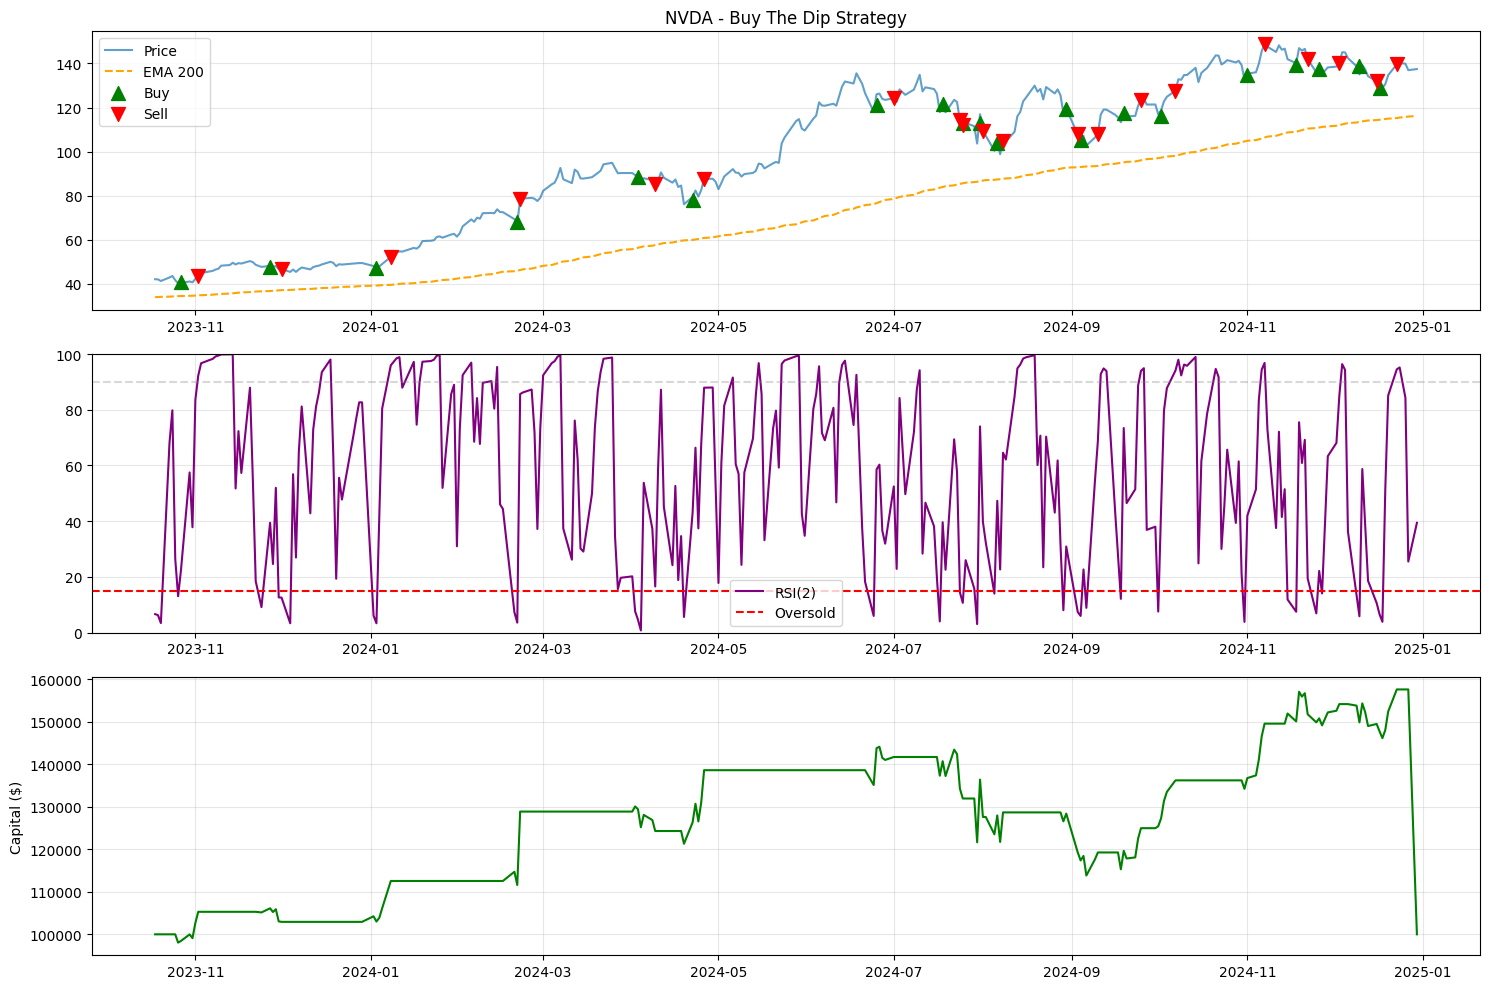

In [10]:
plt.figure(figsize=(15, 10))

# Plot 1: Price & EMA & Signals
ax1 = plt.subplot(3, 1, 1)
ax1.plot(df.index, df['Close'], label='Price', alpha=0.7)
ax1.plot(df.index, df['EMA'], label='EMA 200', color='orange', linestyle='--')

# Plot Entry/Exit markers
if not trades_df.empty:
    # Entry (Green Triangle)
    ax1.scatter(trades_df['entry_date'], trades_df['entry_price'], 
                marker='^', color='green', s=100, label='Buy', zorder=5)
    
    # Exit (Red Triangle)
    # แยกสีตามกำไร/ขาดทุนได้ถ้าขยัน (แต่เอาแค่นี้ก่อน)
    ax1.scatter(trades_df['exit_date'], trades_df['exit_price'], 
                marker='v', color='red', s=100, label='Sell', zorder=5)

ax1.set_title(f'{symbol} - Buy The Dip Strategy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: RSI
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.plot(df.index, df['RSI'], color='purple', label='RSI(2)')
ax2.axhline(y=config.rsi_threshold, color='r', linestyle='--', label='Oversold')
ax2.axhline(y=90, color='gray', linestyle='--', alpha=0.3)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Plot 3: Equity Curve
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
# Adjust equity list length to match df (cut last element usually)
valid_len = min(len(df), len(equity))
ax3.plot(df.index[:valid_len], equity[:valid_len], label='Portfolio Value', color='green')
ax3.set_ylabel('Capital ($)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()